In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
np.random.seed(33550336)

In [49]:
def z(w, x, b):
    return x @ w + b

In [50]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [51]:
def cl(yt, yp):
    return -np.mean(yt * np.log(yp) + (1 - yt) * np.log(1 - yp))

In [52]:
def gwl(X, yt, yp):
    return X.T @ (yp - yt) / len(yt)

In [53]:
def gbl(yt, yp):
    return np.mean(yp - yt)

In [54]:
def score(x1, x2):
    return 2 * x1 - x2 + 0.5

In [67]:
n = 200
x1 = np.random.normal(0, 1, 200)
x2 = np.random.normal(0, 1, 200)

In [80]:
w = np.array([2, -1])
b = 0.5

In [81]:
z = score(x1, x2)

In [82]:
np.shape(z)

(200,)

In [83]:
p = sigmoid(z)

In [84]:
y = (np.random.rand(200) < p).astype(int)

In [85]:
X = np.column_stack([x1, x2])

In [96]:
eta = 0.01

In [97]:
ws = np.array([0, 0])
bs = 0
losses = []

In [98]:
for _ in range(5000):
    yp = sigmoid(X @ ws + bs)
    loss = cl(y, yp)
    losses.append(loss)
    sm = gwl(X, y, yp)
    bm = gbl(y, yp)
    bs = bs - eta * bm
    ws = ws - eta * sm

In [99]:
ws

array([ 1.92212821, -1.088245  ])

In [100]:
bs

np.float64(0.33442108059423997)

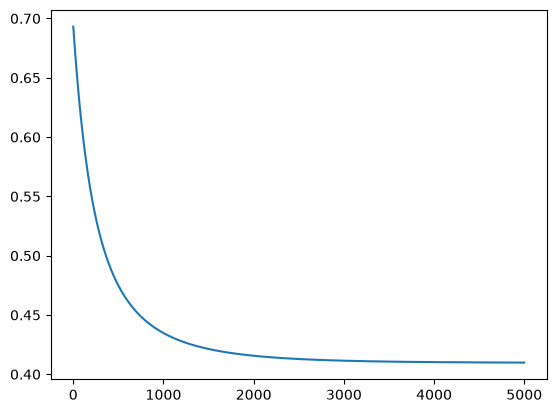

In [101]:
plt.plot(losses)

In [139]:
n = 100
x0 = np.random.randn(100,2) + np.array([0, 0])
y0 = np.zeros(n)
x1 = np.random.randn(100,2) + np.array([3, 3])
y1 = np.ones(n)
x2 = np.random.randn(100,2) + np.array([-2, 4])
y2 = 2 * np.ones(n)
x = np.vstack([x0, x1, x2])
y = np.hstack([y0, y1, y2])

In [140]:
def oh(y, k):
    n = len(y)
    Y = np.zeros((n, k))
    Y[np.arange(n), y.astype(int)] = 1
    return Y

In [141]:
Y = oh(y, 3)

In [142]:
np.shape(Y)

(300, 3)

In [143]:
W = np.zeros((2, 3))
b = np.zeros(3)

In [144]:
sm = x @ W + b

In [145]:
def softmax(z):
    if z.ndim == 1:
        return np.exp(z) / np.sum(np.exp(z))
    else:
        return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)

In [146]:
probs = softmax(sm)

In [154]:
def cce(y, p):
    n = len(y)
    cp = p[np.arange(n), y.astype(int)]
    return -np.mean(np.log(cp))

In [164]:
def gradw(X, yp, yt):
    return X.T @ (yp - yt) / len(X)

In [165]:
def gradb(yp, yt):
    return np.mean(yp - yt, axis = 0)

In [166]:
eta = 0.1
losses = []
for _ in range(200):
    sm = x @ W + b
    probs = softmax(sm)
    loss = cce(y, probs)
    losses.append(loss)
    grad_w = gradw(x, probs, Y)
    grad_b = gradb(probs, Y)
    W = W - eta * grad_w
    b = b - eta * grad_b

In [167]:
W

array([[-0.19706693,  1.01780042, -0.82073349],
       [-0.77779127,  0.22501499,  0.55277627]])

In [168]:
b

array([ 1.83423597, -0.8971412 , -0.93709477])

In [169]:
print(np.sum(Y, axis = 0))

[100. 100. 100.]


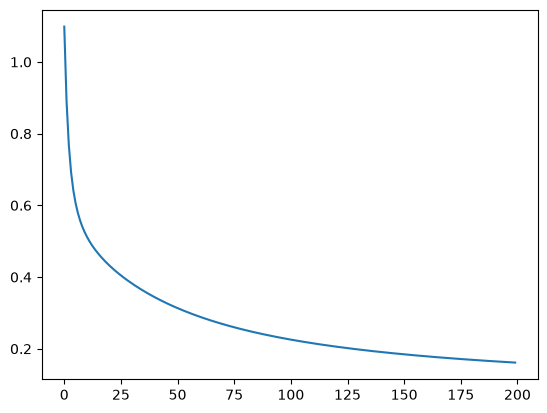

In [170]:
plt.plot(losses)

In [174]:
sm = x @ W + b
probs = softmax(sm)

predictions = np.argmax(probs, axis=1)
accuracy = np.mean(predictions == y)

print(accuracy)

0.9566666666666667
